In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the training and test data
training_data = pd.read_csv('training_sets/sentiment-topic/sentiment-topic-train.tsv', sep='\t', header=0)  
test_data = pd.read_csv('test_sets/sentiment-topic-test.tsv', sep='\t')

In [ ]:
def plot_topics(df, title):
    # Count occurrences of each sentiment per topic
    topic_counts = df.groupby(["topic", "sentiment"]).size().reset_index(name="count")

    # The topics
    topics = ["book", "movie", "sports"]

    # Create subplots and adjust size based on number of topics
    _, axes = plt.subplots(1, len(topics), figsize=(len(topics) * 5, 5), sharey=True)

    for ax, topic in zip(axes, topics):
        # Filter data for the current topic
        subset = topic_counts[topic_counts["topic"] == topic]

        # Get all sentiments and ensure each sentiment is represented
        all_sentiments = ["positive", "neutral", "negative"]
        for sentiment in all_sentiments:
            if sentiment not in subset["sentiment"].values:
                subset = pd.concat([subset, pd.DataFrame({"topic": [topic], "sentiment": [sentiment], "count": [0]})], ignore_index=True)

        # Sort by predefined sentiment order (positive, neutral, negative)
        subset = subset.set_index("sentiment").reindex(all_sentiments).reset_index()

        # Create bar plot
        sns.barplot(x="sentiment", y="count", data=subset, ax=ax, hue="sentiment", palette=['#6F8E7C', '#A26360', '#3C5D81'], order=all_sentiments, edgecolor='black', linewidth=0.5)

        # Titles and labels
        ax.set_title(f"Sentiment Distribution for {topic}", fontsize=14, fontweight="bold")
        ax.set_xlabel("Sentiment", fontsize=13, fontweight="bold", labelpad=15)
        ax.set_ylabel("Count", fontsize=13, fontweight="bold", labelpad=15)
        ax.set_xticks(range(len(all_sentiments)))
        ax.set_xticklabels(all_sentiments, rotation=0, fontsize=11)
        # Add horizontal lines
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
    # Add overall title
    plt.suptitle(title, fontsize=19, fontweight="bold")

    plt.tight_layout()
    plt.show()


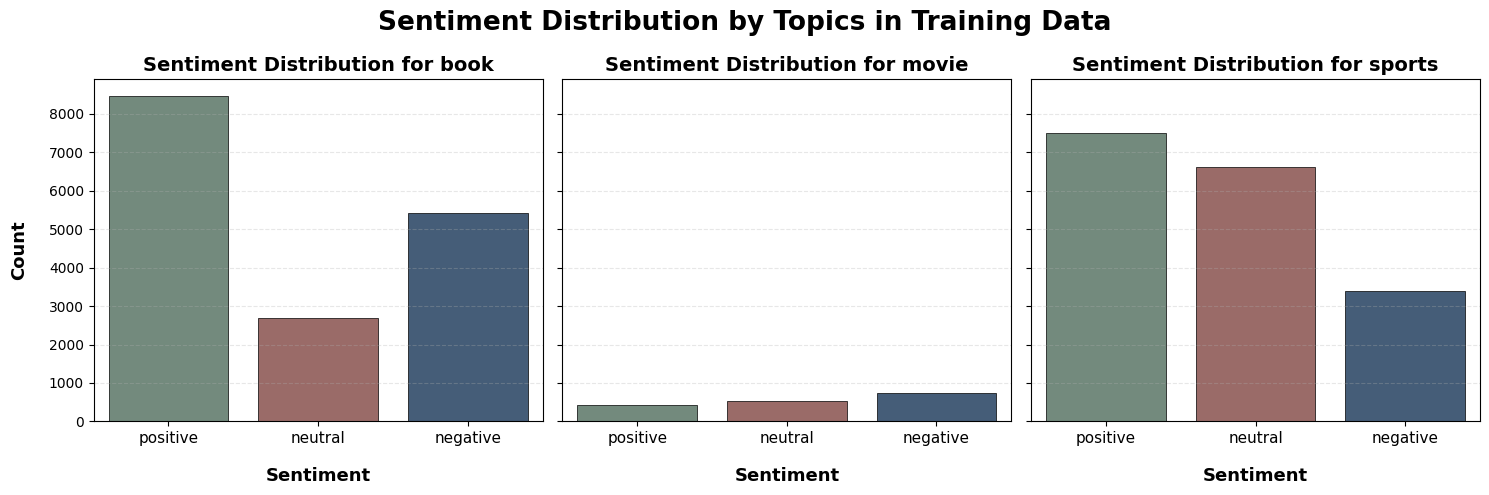

In [13]:
# Get plots for training data
plot_topics(training_data, "Sentiment Distribution by Topics in Training Data")

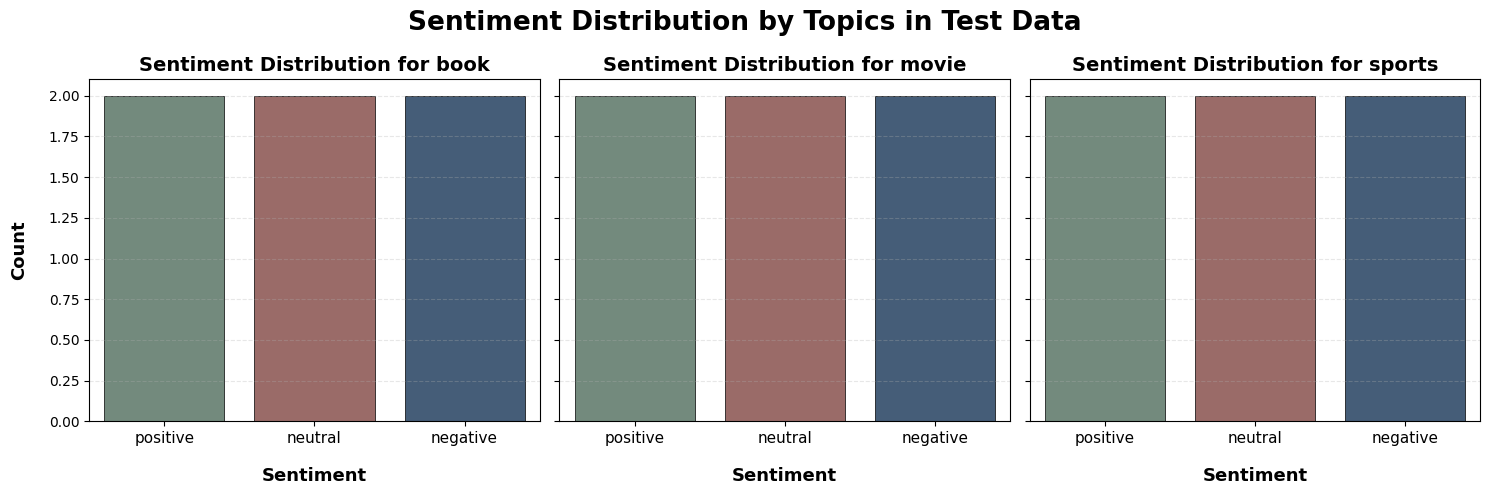

In [14]:
# Get plots for test data
plot_topics(test_data, "Sentiment Distribution by Topics in Test Data")